# Wilson-Cowan Higher-Order Model

---
## **1. Theoretical Introduction**

### **1.1. Wilson-Cowan Model with Higher-Order Interactions**
The Wilson-Cowan model with higher-order interactions extends the classic model by incorporating triadic interactions between excitatory populations.

#### **Model Equations:**
- **Excitatory Population:**
  $$
  \tau_E \frac{dE_i}{dt} = -E_i + S\left(c_{EE} E_i - c_{IE} I_i + P + K_3 \sum_{j,k} T_{ijk} E_j E_k\right)
  $$

- **Inhibitory Population:**
  $$
  \tau_I \frac{dI_i}{dt} = -I_i + S\left(c_{EI} E_i - c_{II} I_i + Q\right)
  $$

#### **Sigmoid Function:**
$$
S(v) = \frac{1}{1 + e^{-a v}}
$$

#### **Higher-Order Interaction Tensor:**
$$
I_i^{net} = K_3 \sum_{j,k} T_{ijk} E_j E_k
$$

---
## **2. Initial Setup**
We import the functions already defined in the `Scripts` folder.


In [2]:
import sys
sys.path.append('../')  # Ensure Python can find the 'Scripts' folder

#from Scripts.parameters import *
from Scripts_BackUps.parameters_random import *
from Scripts_BackUps.dynamics import *
from Scripts_BackUps.simulation import *
from Scripts_BackUps.oscillation_detection import *
from Scripts_BackUps.metrics import *
from Scripts_BackUps.visualization import *

print("Functions loaded successfully.")


Functions loaded successfully.


---
## **3. Basic Simulation with Higher-Order Interactions and Signal Plotting**
We simulate the model with higher-order interactions and visualize the signals.


Total timesteps: 10000
Analysis timesteps: 9001

Node 0:
  E: mean=0.4983, std=0.2157, range=[0.1918, 0.8032]
  I: mean=0.4726, std=0.1495, range=[0.2517, 0.6959]

Node 1:
  E: mean=0.4986, std=0.2154, range=[0.1957, 0.8016]
  I: mean=0.4727, std=0.1495, range=[0.2514, 0.6957]

Node 2:
  E: mean=0.4983, std=0.2156, range=[0.1934, 0.8027]
  I: mean=0.4726, std=0.1495, range=[0.2521, 0.6958]


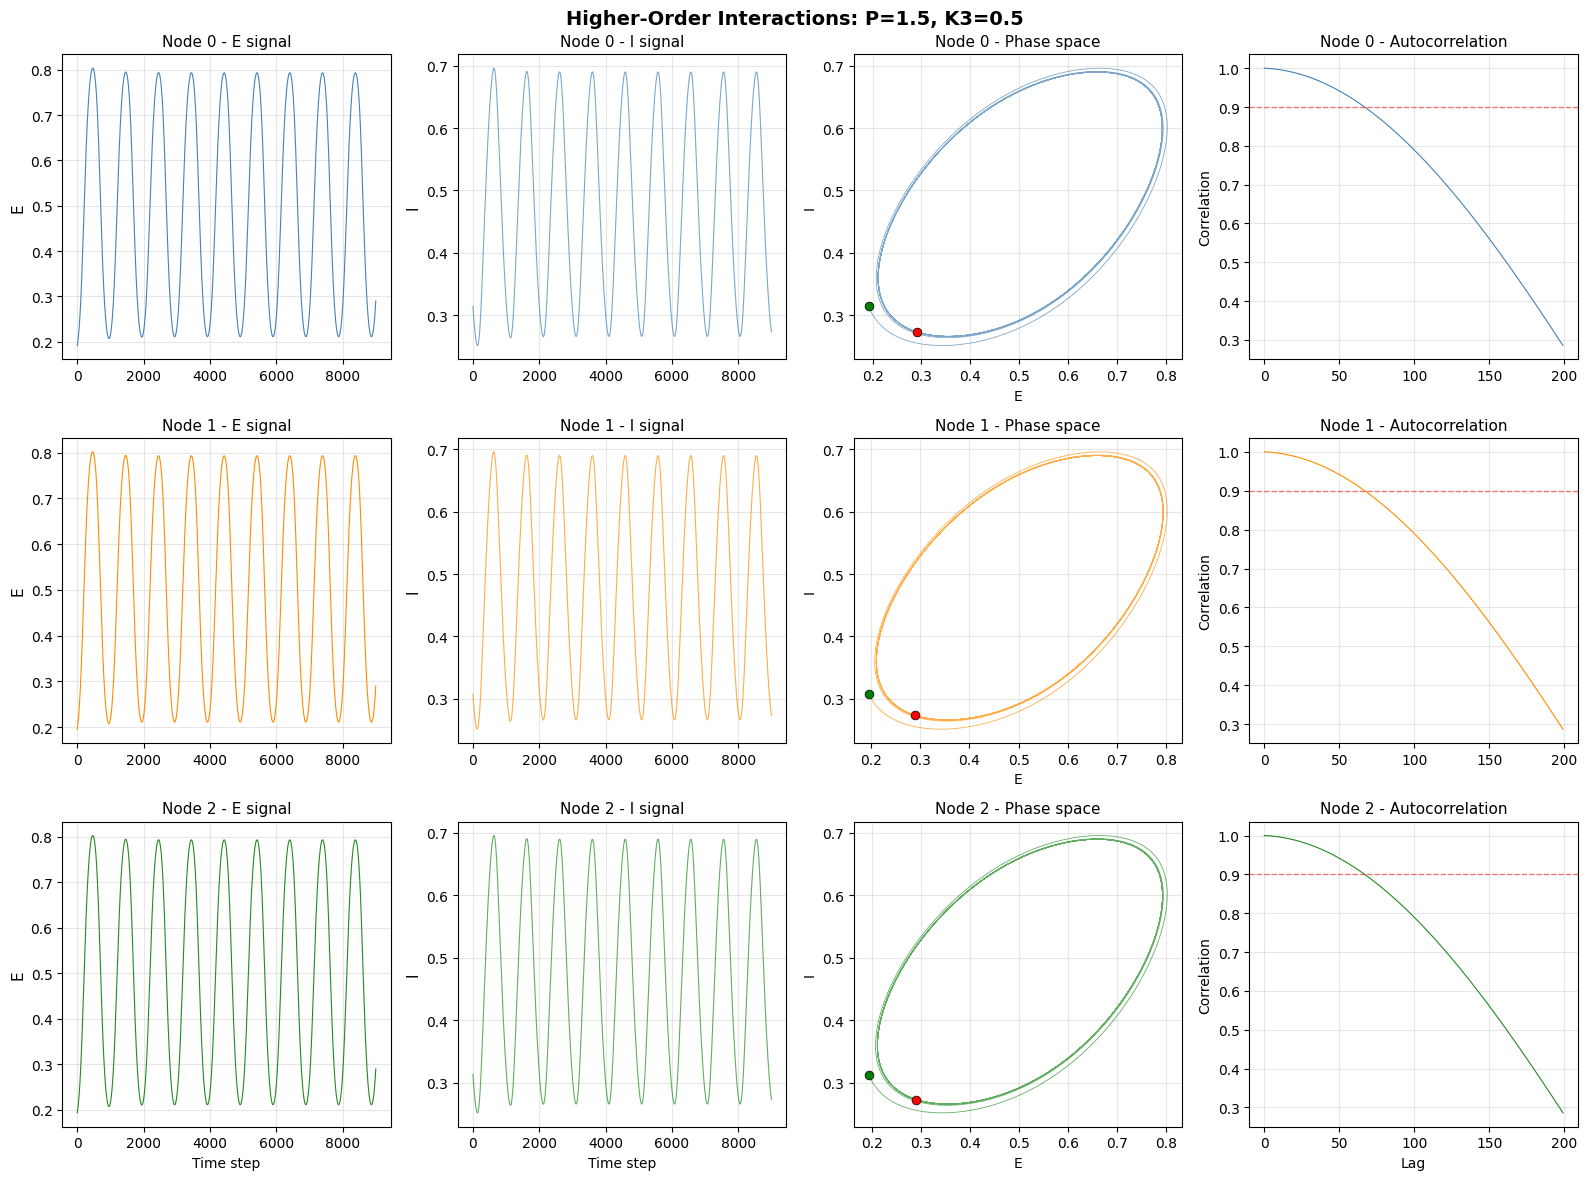

In [3]:
# Simulation parameters
P_sim = 1.5 
K3_sim = 0.5  

# Initial state
state0 = 0.1 * np.random.randn(2 * N_nodes)

# Simulation using the existing function for higher-order interactions
t, states = simulate_wc_higher_order(state0, P_sim, K3_sim, T_ho, T, dt)

# Extract signals
E = states[:, :N_nodes]
I = states[:, N_nodes:]

# Visualization using the existing function
plot_detailed_signals(t, states, N_nodes, P_sim=P_sim, K3_sim=K3_sim, title="Higher-Order Interactions")


In [4]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Asumiendo que E es tu matriz de señales (N x 3)
# Submuestreo para fluidez
step = 5
E_sub = E[::step]

# Crear subplots 2D
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("E1 vs E2", "E1 vs E3", "E2 vs E3")
)

# E1 vs E2
fig.add_trace(
    go.Scatter(
        x=E_sub[:, 0],
        y=E_sub[:, 1],
        mode='markers',
        marker=dict(size=5),
        name='E1 vs E2'
    ),
    row=1, col=1
)

# E1 vs E3
fig.add_trace(
    go.Scatter(
        x=E_sub[:, 0],
        y=E_sub[:, 2],
        mode='markers',
        marker=dict(size=5),
        name='E1 vs E3'
    ),
    row=1, col=2
)

# E2 vs E3
fig.add_trace(
    go.Scatter(
        x=E_sub[:, 1],
        y=E_sub[:, 2],
        mode='markers',
        marker=dict(size=5),
        name='E2 vs E3'
    ),
    row=1, col=3
)

fig.update_layout(
    title_text="Pairwise 2D Activity",
    height=400,
    width=900,
    showlegend=False
)

fig.update_xaxes(title_text="E_i", row=1, col=1)
fig.update_yaxes(title_text="E_j", row=1, col=1)
fig.update_xaxes(title_text="E_i", row=1, col=2)
fig.update_yaxes(title_text="E_j", row=1, col=2)
fig.update_xaxes(title_text="E_i", row=1, col=3)
fig.update_yaxes(title_text="E_j", row=1, col=3)

fig.show()


---
## **4. Oscillation Detection in $(P \times K_3)$ Space**
We perform a parameter sweep to detect oscillations in the $(P \times K_3)$ space.


In [ ]:
# Matrix to store oscillation detection
oscillation_map = np.zeros((len(P_values), len(K3_values)), dtype=int)

# Initial state
state0 = 0.1 * np.random.randn(2 * N_nodes)

for i, P_val in enumerate(P_values):
    for j, K3_val in enumerate(K3_values):
        # Simulation using the existing function for higher-order interactions
        t, states = simulate_wc_higher_order(state0, P_val, K3_val, T_ho, T, dt)

        # Remove transient
        start_idx = len(states) // 2
        E = states[start_idx:, :N_nodes]
        I = states[start_idx:, N_nodes:]

        E_node = E[:, 0]
        I_node = I[:, 0]

        # Oscillation detection using the existing function
        is_lc, _, _, _ = detect_limit_cycle_poincare(E_node, I_node, dt)
        oscillation_map[i, j] = int(is_lc)

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing function
plot_oscillation_map(oscillation_map, P_values, K3_values, title="Oscillation Detection (P-K3)")


---
## **5. Higher-Order Metrics with Higher-Order Interactions**
We calculate higher-order metrics to analyze interactions in the system with higher-order interactions.


Progress: 5/20
Progress: 10/20
Progress: 15/20
Progress: 20/20


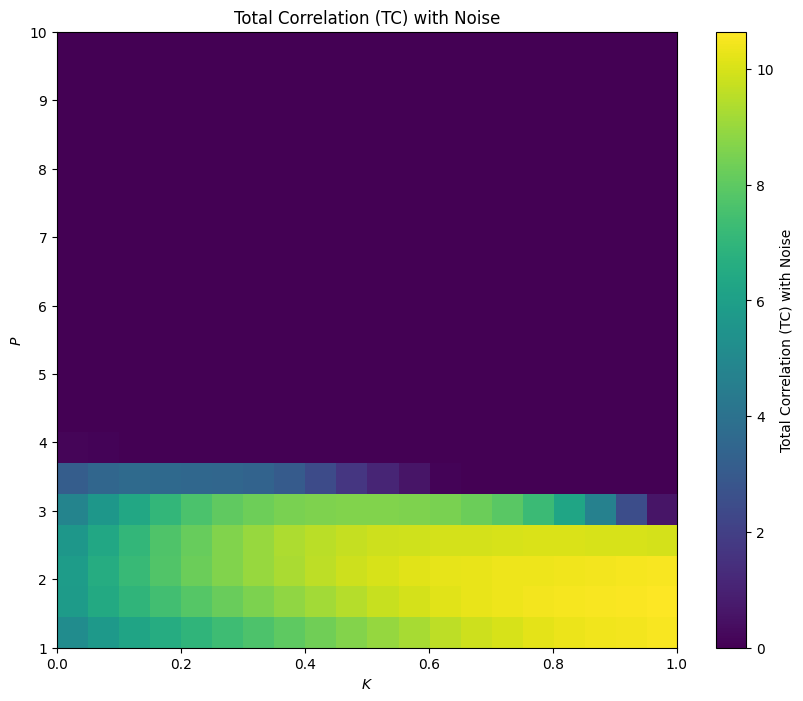

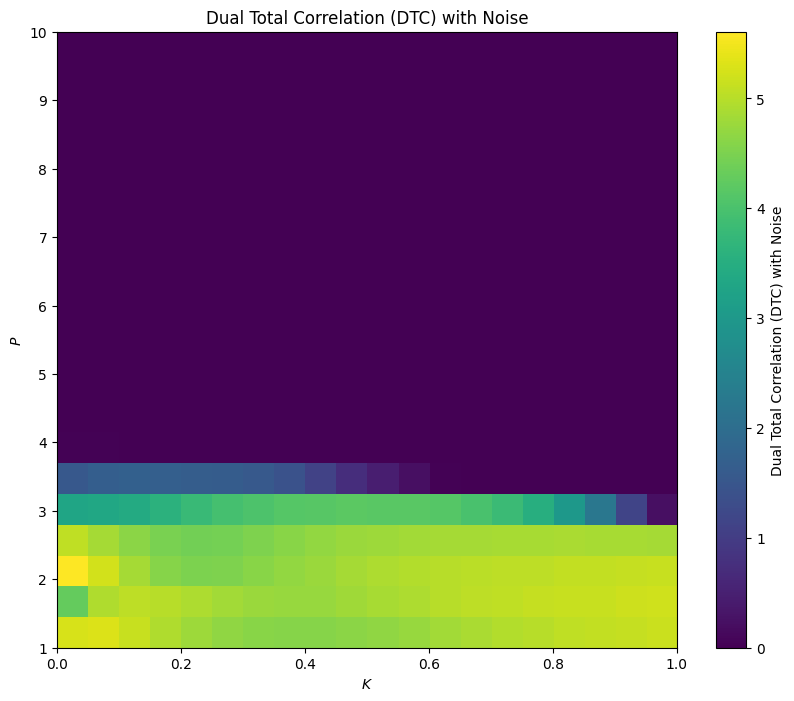

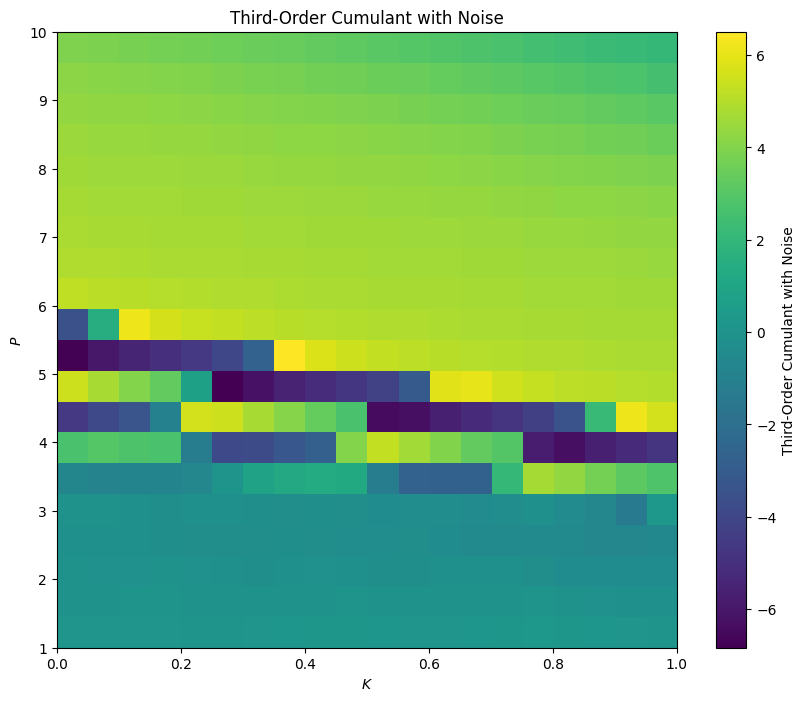

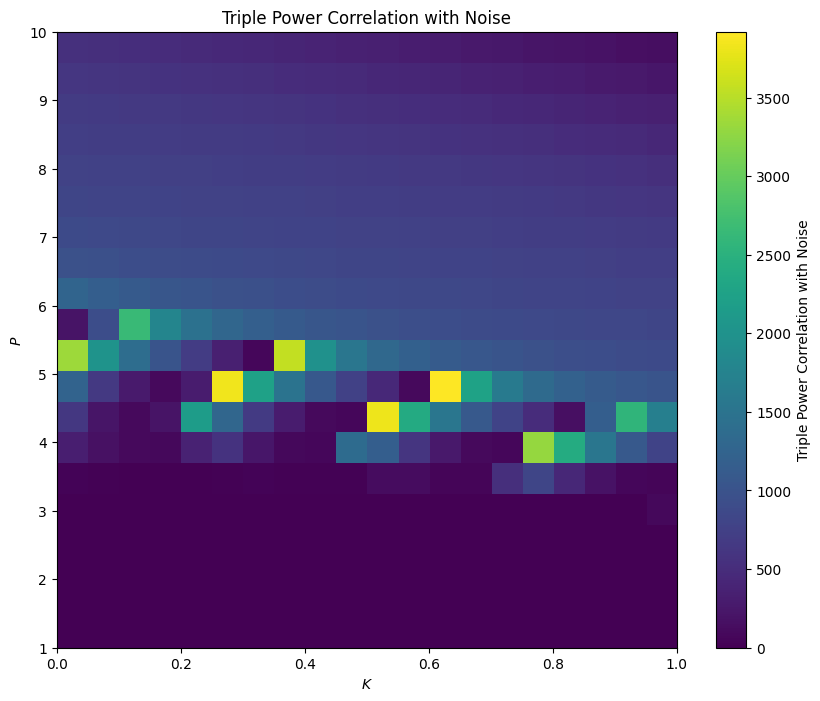

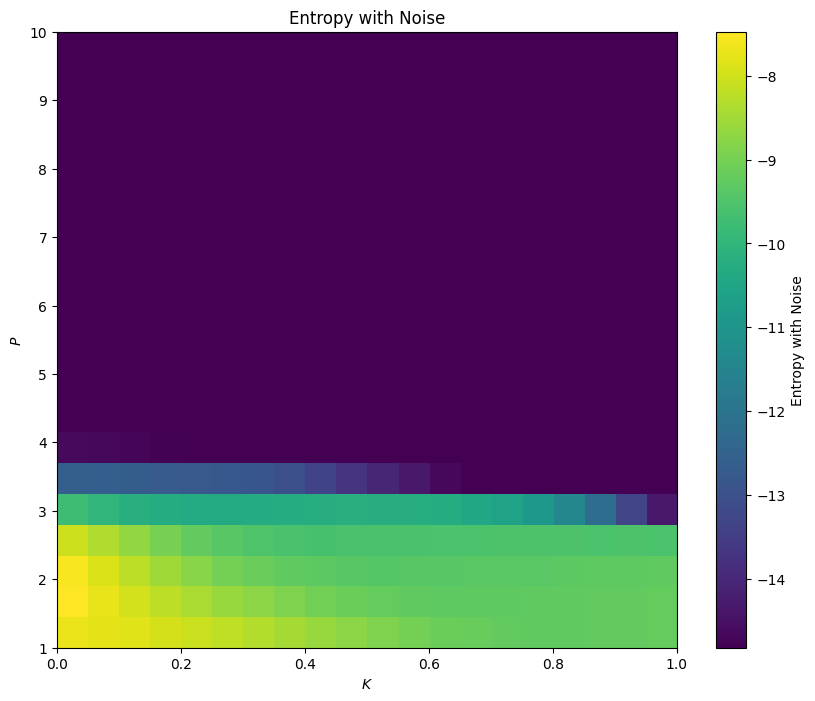

In [4]:
# Matrices to store metrics with noise
TC_map_noise = np.zeros((len(P_values), len(K3_values)))
DTC_map_noise = np.zeros((len(P_values), len(K3_values)))
Cumulant_map_noise = np.zeros((len(P_values), len(K3_values)))
PowerCorr_map_noise = np.zeros((len(P_values), len(K3_values)))
Entropy_map_noise = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica

state0 = 0.1 * np.random.randn(2 * N_nodes)

for i, P_val in enumerate(P_values):
    for j, K3_val in enumerate(K3_values):
        # Simulation with noise using the existing function for higher-order interactions
        t, states = simulate_wc_higher_order(state0, P_val, K3_val, T_ho, T, dt)

        # Remove transient
        start_idx = int(0.3 * len(t))
        E = states[start_idx:, :N_nodes]

        # Data matrix for higher-order metrics
        X = E.copy()

        # Covariance matrix
        Sigma = np.cov(X.T)

        # Higher-order metrics using the existing functions
        TC_map_noise[i, j] = TC_gauss(Sigma)
        DTC_map_noise[i, j] = DTC_gauss(Sigma)
        Entropy_map_noise[i, j] = entropy_gauss(Sigma)  # Cálculo de la entropía
        if X.shape[1] == 3:
            Cumulant_map_noise[i, j] = cumulants(X)
            PowerCorr_map_noise[i, j] = powercorr(X)

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing functions
plot_metrics_map(TC_map_noise, P_values, K3_values, title="Total Correlation (TC) with Noise")
plot_metrics_map(DTC_map_noise, P_values, K3_values, title="Dual Total Correlation (DTC) with Noise")
plot_metrics_map(Cumulant_map_noise, P_values, K3_values, title="Third-Order Cumulant with Noise")
plot_metrics_map(PowerCorr_map_noise, P_values, K3_values, title="Triple Power Correlation with Noise")
plot_metrics_map(Entropy_map_noise, P_values, K3_values, title="Entropy with Noise") 

---
## **6. Model with Stochastic Noise and Higher-Order Interactions**
We add stochastic noise to the excitatory population (E) using the Euler-Maruyama method with higher-order interactions.

To include biological noise, we extend the excitatory population dynamics using the **Euler-Maruyama method**:

$$
E_i(t + \Delta t) = E_i(t) + \frac{\Delta t}{\tau_E} \left(-E_i(t) + S\left(c_{EE} E_i - c_{IE} I_i + P + K_3 \sum_{j,k} T_{ijk} E_j E_k\right)\right) + \frac{\sigma_E \sqrt{\Delta t}}{\tau_E} \xi_i
$$

- $(\sigma_E)$: Noise intensity for the excitatory population.
- $(\xi_i \sim \mathcal{N}(0, 1))$: Gaussian white noise.

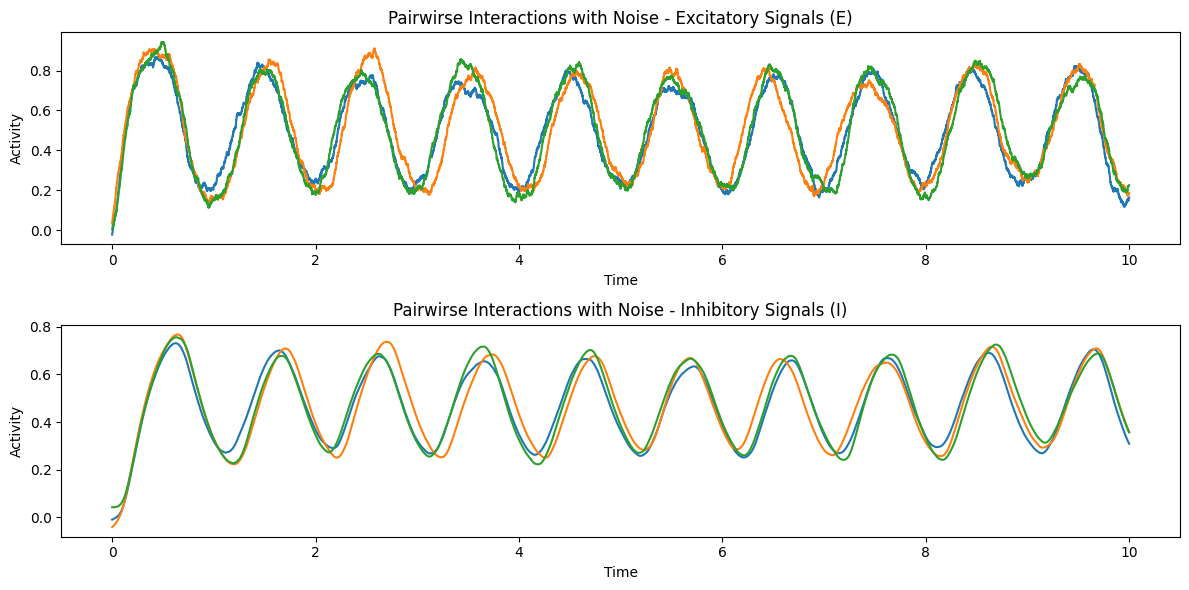

Total timesteps: 10000
Analysis timesteps: 9001

Node 0:
  E: mean=0.4965, std=0.2032, range=[0.1149, 0.8391]
  I: mean=0.4705, std=0.1425, range=[0.2510, 0.7057]

Node 1:
  E: mean=0.5026, std=0.2184, range=[0.1506, 0.9117]
  I: mean=0.4751, std=0.1515, range=[0.2224, 0.7373]

Node 2:
  E: mean=0.4994, std=0.2225, range=[0.1384, 0.8574]
  I: mean=0.4743, std=0.1535, range=[0.2221, 0.7256]


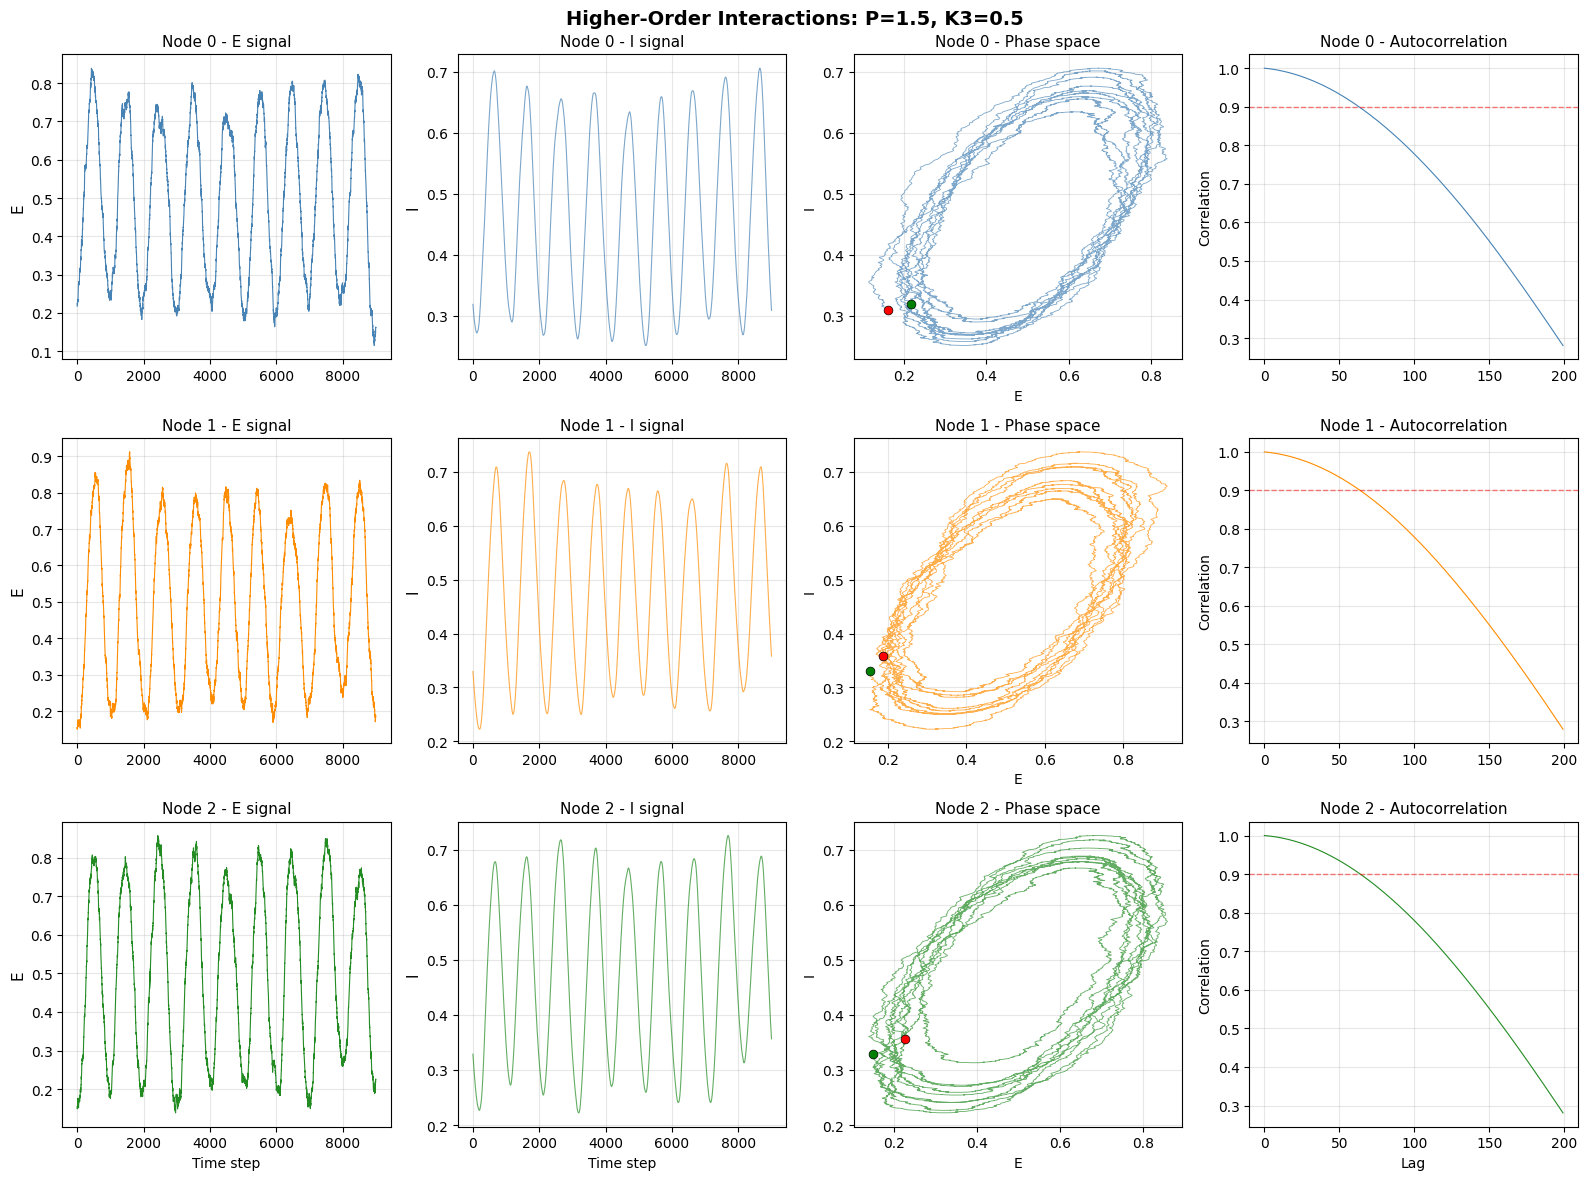

In [5]:
# Simulation parameters with noise
sigma_E = 0.1

# Simulation with noise using the existing function for higher-order interactions
t, states = simulate_wc_stochastic(state0, P_sim, K3_sim, M, T, dt, sigma_E=sigma_E, higher_order=True, T_ho=T_ho)

# Extract signals
E = states[:, :N_nodes]
I = states[:, N_nodes:]

# Visualization using the existing function
plot_signals(t, E, I, title="Pairwirse Interactions with Noise")

# Visualization using the existing function
plot_detailed_signals(t, states, N_nodes, P_sim=P_sim, K3_sim=K3_sim, title="Higher-Order Interactions")


In [6]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Asumiendo que E es tu matriz de señales (N x 3)
# Submuestreo para fluidez
step = 5
E_sub = E[::step]

# Crear subplots 2D
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("E1 vs E2", "E1 vs E3", "E2 vs E3")
)

# E1 vs E2
fig.add_trace(
    go.Scatter(
        x=E_sub[:, 0],
        y=E_sub[:, 1],
        mode='markers',
        marker=dict(size=5),
        name='E1 vs E2'
    ),
    row=1, col=1
)

# E1 vs E3
fig.add_trace(
    go.Scatter(
        x=E_sub[:, 0],
        y=E_sub[:, 2],
        mode='markers',
        marker=dict(size=5),
        name='E1 vs E3'
    ),
    row=1, col=2
)

# E2 vs E3
fig.add_trace(
    go.Scatter(
        x=E_sub[:, 1],
        y=E_sub[:, 2],
        mode='markers',
        marker=dict(size=5),
        name='E2 vs E3'
    ),
    row=1, col=3
)

fig.update_layout(
    title_text="Pairwise 2D Activity",
    height=400,
    width=900,
    showlegend=False
)

fig.update_xaxes(title_text="E_i", row=1, col=1)
fig.update_yaxes(title_text="E_j", row=1, col=1)
fig.update_xaxes(title_text="E_i", row=1, col=2)
fig.update_yaxes(title_text="E_j", row=1, col=2)
fig.update_xaxes(title_text="E_i", row=1, col=3)
fig.update_yaxes(title_text="E_j", row=1, col=3)

fig.show()


---
## **7. Oscillation Detection in $(P \times K$) Space** with noise
We perform a parameter sweep to detect oscillations in the $(P \times K$) space.


Progress: 5/20
Progress: 10/20
Progress: 15/20
Progress: 20/20


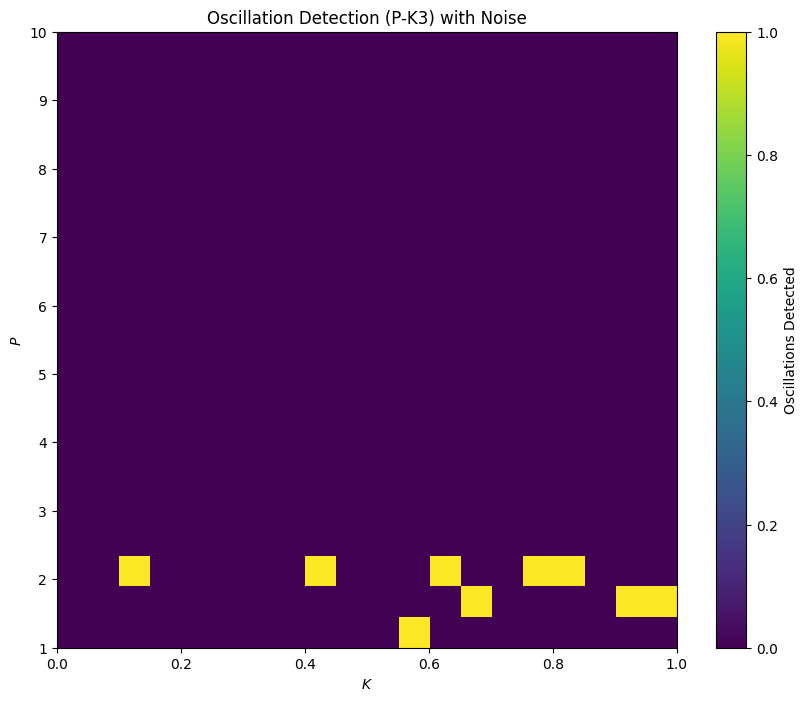

In [6]:
# Matrix to store oscillation detection with noise
oscillation_map_noise = np.zeros((len(P_values), len(K3_values)), dtype=int)

state0 = 0.1 * np.random.randn(2 * N_nodes)

for i, P_val in enumerate(P_values):
    for j, K3_val in enumerate(K3_values):
        # Simulation with noise using the existing function for higher-order interactions
        t, states = simulate_wc_stochastic(state0, P_val, K3_val, M, T, dt, sigma_E=sigma_E, higher_order=True, T_ho=T_ho)

        # Remove transient
        start_idx = len(states) // 2
        E = states[start_idx:, :N_nodes]
        I = states[start_idx:, N_nodes:]

        E_node = E[:, 0]
        I_node = I[:, 0]

        # Oscillation detection using the existing function
        is_lc, _, _, _ = detect_limit_cycle_poincare(E_node, I_node, dt)
        oscillation_map_noise[i, j] = int(is_lc)

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing function
plot_oscillation_map(oscillation_map_noise, P_values, K3_values, title="Oscillation Detection (P-K3) with Noise")


---
## **8. Higher-Order Metrics with noise**
We calculate higher-order metrics to analyze interactions in the system.


Progress: 5/20
Progress: 10/20
Progress: 15/20
Progress: 20/20


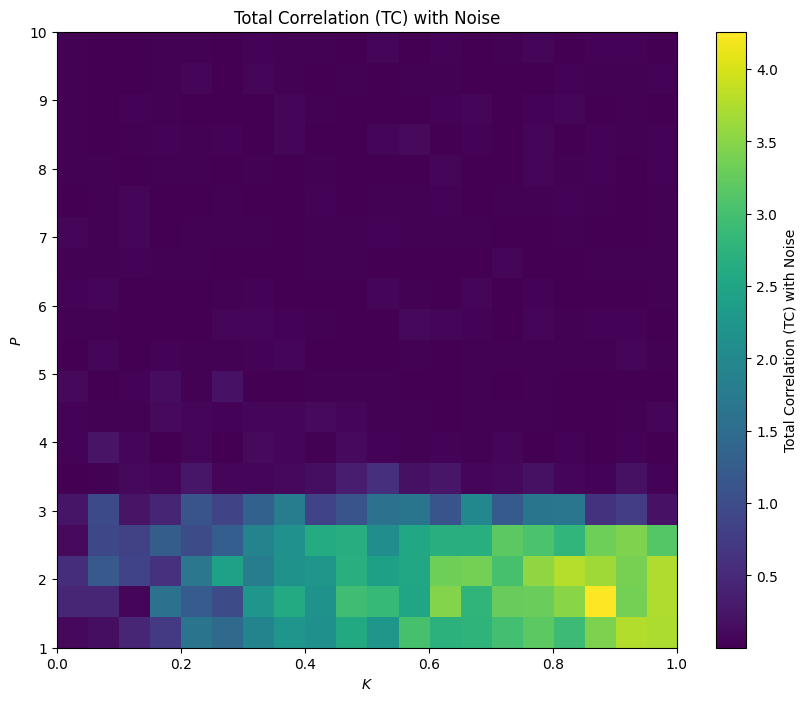

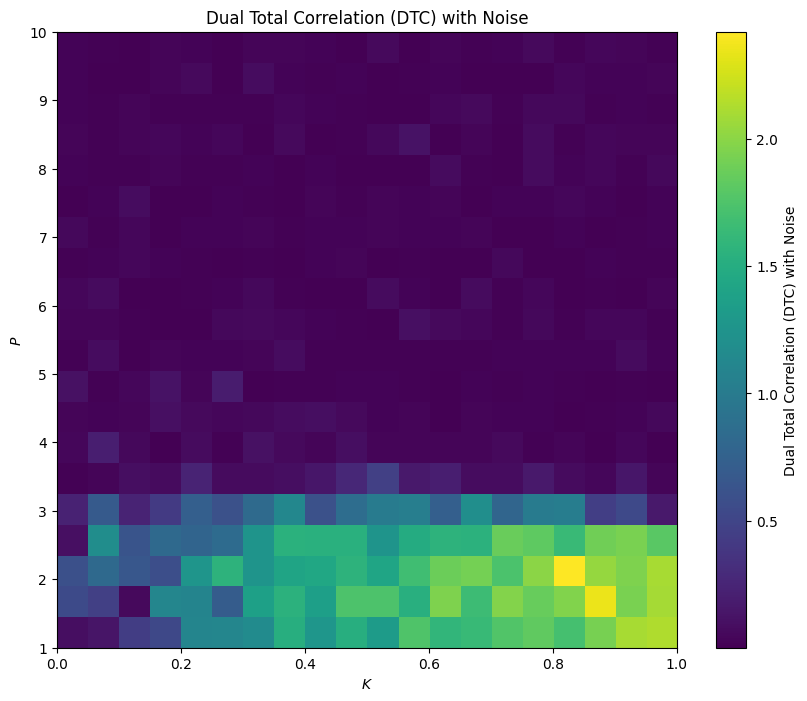

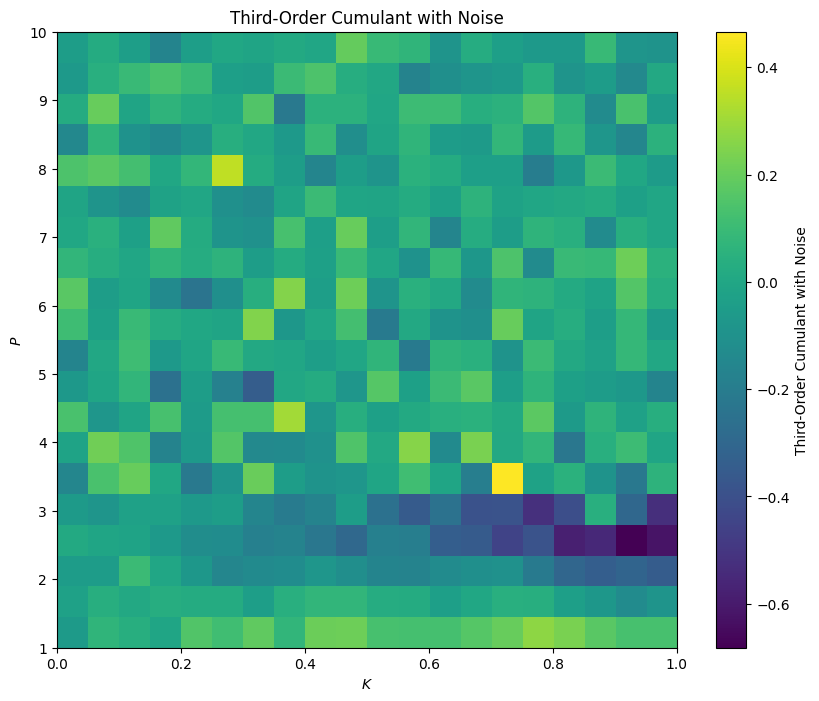

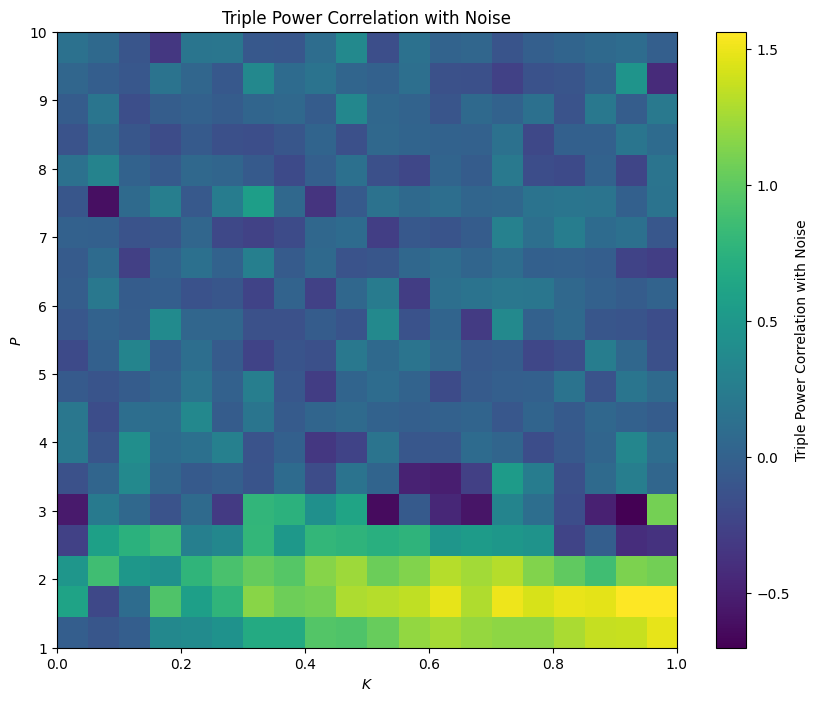

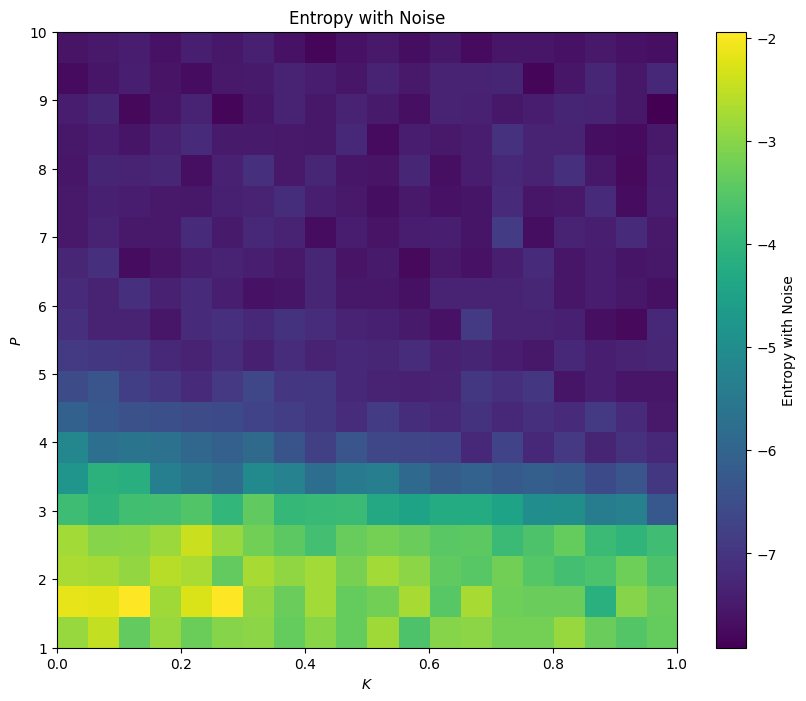

In [7]:
# Matrices to store metrics with noise
TC_map_noise = np.zeros((len(P_values), len(K3_values)))
DTC_map_noise = np.zeros((len(P_values), len(K3_values)))
Cumulant_map_noise = np.zeros((len(P_values), len(K3_values)))
PowerCorr_map_noise = np.zeros((len(P_values), len(K3_values)))
Entropy_map_noise = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica

state0 = 0.1 * np.random.randn(2 * N_nodes)

for i, P_val in enumerate(P_values):
    for j, K3_val in enumerate(K3_values):
        # Simulation with noise using the existing function for higher-order interactions
        t, states = simulate_wc_stochastic(state0, P_val, K3_val, M, T, dt, sigma_E=sigma_E, higher_order=True, T_ho=T_ho)

        # Remove transient
        start_idx = int(0.3 * len(t))
        E = states[start_idx:, :N_nodes]

        # Data matrix for higher-order metrics
        X = E.copy()

        # Covariance matrix
        Sigma = np.cov(X.T)

        # Higher-order metrics using the existing functions
        TC_map_noise[i, j] = TC_gauss(Sigma)
        DTC_map_noise[i, j] = DTC_gauss(Sigma)
        Entropy_map_noise[i, j] = entropy_gauss(Sigma)  # Cálculo de la entropía
        if X.shape[1] == 3:
            Cumulant_map_noise[i, j] = cumulants(X)
            PowerCorr_map_noise[i, j] = powercorr(X)

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing functions
plot_metrics_map(TC_map_noise, P_values, K3_values, title="Total Correlation (TC) with Noise")
plot_metrics_map(DTC_map_noise, P_values, K3_values, title="Dual Total Correlation (DTC) with Noise")
plot_metrics_map(Cumulant_map_noise, P_values, K3_values, title="Third-Order Cumulant with Noise")
plot_metrics_map(PowerCorr_map_noise, P_values, K3_values, title="Triple Power Correlation with Noise")
plot_metrics_map(Entropy_map_noise, P_values, K3_values, title="Entropy with Noise")  
